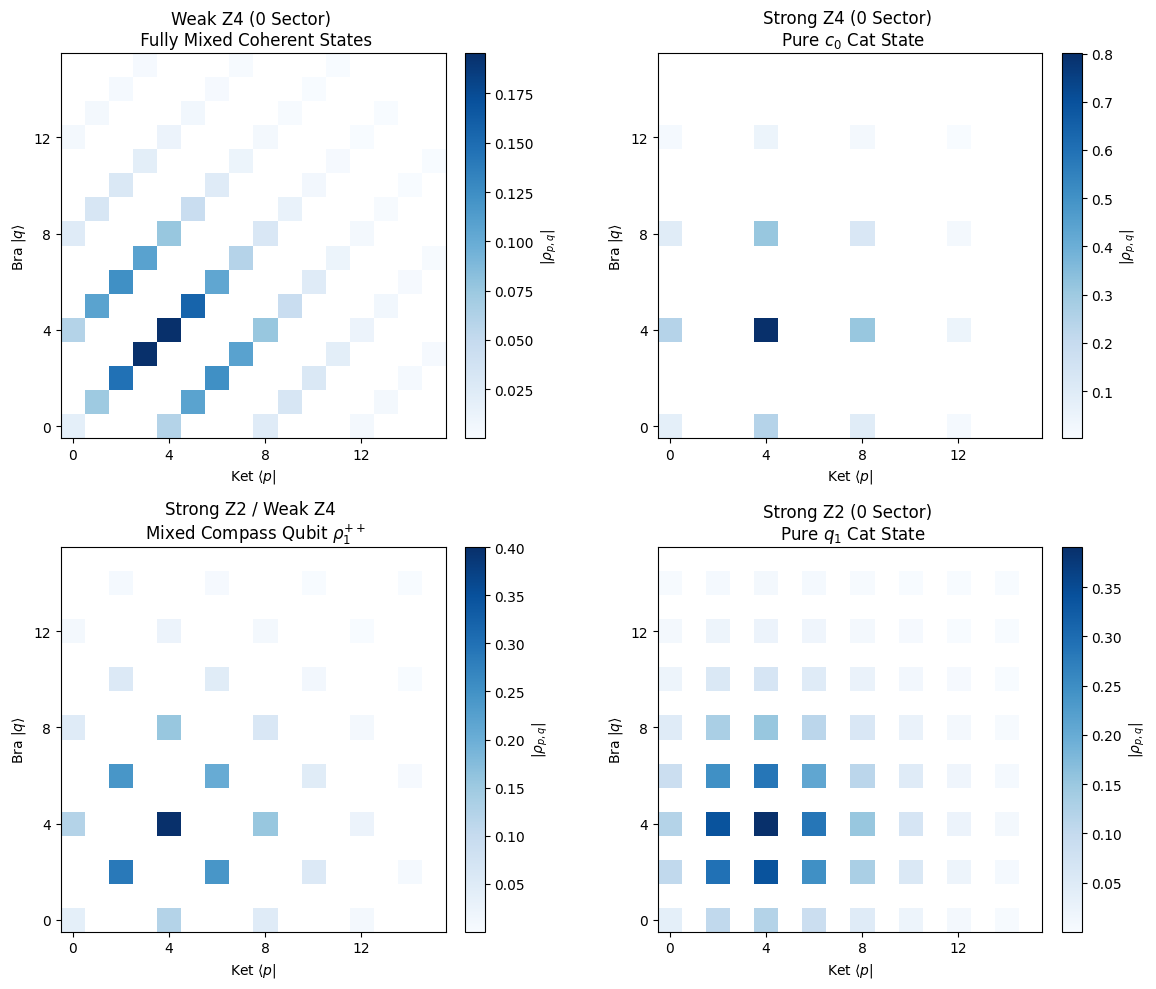

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial

# Parameters
alpha = 2.0  # Coherent state amplitude
M = 16       # Fock space cutoff

# 1. Generate the Coherent State in Fock Basis
def coherent_state(alpha_val, cutoff):
    state = np.zeros(cutoff, dtype=complex)
    for n in range(cutoff):
        state[n] = (alpha_val**n / np.sqrt(factorial(n))) * np.exp(-0.5 * np.abs(alpha_val)**2)
    return state

# 2. Define the Base Coherent States
st_a = coherent_state(alpha, M)
st_ia = coherent_state(alpha * 1j, M)
st_ma = coherent_state(-alpha, M)
st_mia = coherent_state(-alpha * 1j, M)

# 3. Construct the Superposition States (Cats/Compass)
# Normalize a state vector
def normalize(state):
    return state / np.linalg.norm(state)

c0 = normalize(st_a + st_ia + st_ma + st_mia)
c1 = normalize(st_a - 1j*st_ia - st_ma + 1j*st_mia)
c3 = normalize(st_a + 1j*st_ia - st_ma - 1j*st_mia)
c2 = normalize(st_a - st_ia + st_ma - st_mia)
q1 = normalize(st_a + st_ma)

# 4. Construct Density Matrices
def outer_product(state):
    return np.outer(state, state.conjugate())

# Weak Z4 (Statistical mixture of 4 coherent states)
rho_weak_z4 = 0.25 * (outer_product(st_a) + outer_product(st_ia) + 
                      outer_product(st_ma) + outer_product(st_mia))

# Strong Z4 (Pure c0 cat state)
rho_strong_z4 = outer_product(c0)

# Strong Z2 / Weak Z4 (Mixed compass qubit state)
rho_mixed_compass = 0.5 * outer_product(c0) + 0.5 * outer_product(c2)

# Strong Z2 (Pure even parity q1 state)
rho_strong_z2 = outer_product(q1)

# 5. Plotting Function
def plot_density_matrix(ax, rho, title):
    # Get absolute values of the density matrix
    abs_rho = np.abs(rho)
    
    # Mask near-zero values to show up as white (like the paper's figures)
    abs_rho[abs_rho < 1e-4] = np.nan 
    
    cmap = plt.cm.Blues
    cmap.set_bad(color='white')
    
    im = ax.imshow(abs_rho, cmap=cmap, origin='lower', extent=[-0.5, M-0.5, -0.5, M-0.5])
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Ket $\\langle p |$')
    ax.set_ylabel('Bra $| q \\rangle$')
    
    # Set ticks to show Fock states
    ax.set_xticks(np.arange(0, M, 4))
    ax.set_yticks(np.arange(0, M, 4))
    
    return im

# Generate the 2x2 Plot Grid
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

im1 = plot_density_matrix(axs[0, 0], rho_weak_z4, "Weak Z4 (0 Sector) \n Fully Mixed Coherent States")
fig.colorbar(im1, ax=axs[0, 0], fraction=0.046, pad=0.04, label="$|\\rho_{p,q}|$")

im2 = plot_density_matrix(axs[0, 1], rho_strong_z4, "Strong Z4 (0 Sector) \n Pure $c_0$ Cat State")
fig.colorbar(im2, ax=axs[0, 1], fraction=0.046, pad=0.04, label="$|\\rho_{p,q}|$")

im3 = plot_density_matrix(axs[1, 0], rho_mixed_compass, "Strong Z2 / Weak Z4 \n Mixed Compass Qubit $\\rho_1^{++}$")
fig.colorbar(im3, ax=axs[1, 0], fraction=0.046, pad=0.04, label="$|\\rho_{p,q}|$")

im4 = plot_density_matrix(axs[1, 1], rho_strong_z2, "Strong Z2 (0 Sector) \n Pure $q_1$ Cat State")
fig.colorbar(im4, ax=axs[1, 1], fraction=0.046, pad=0.04, label="$|\\rho_{p,q}|$")

plt.tight_layout()
plt.show()

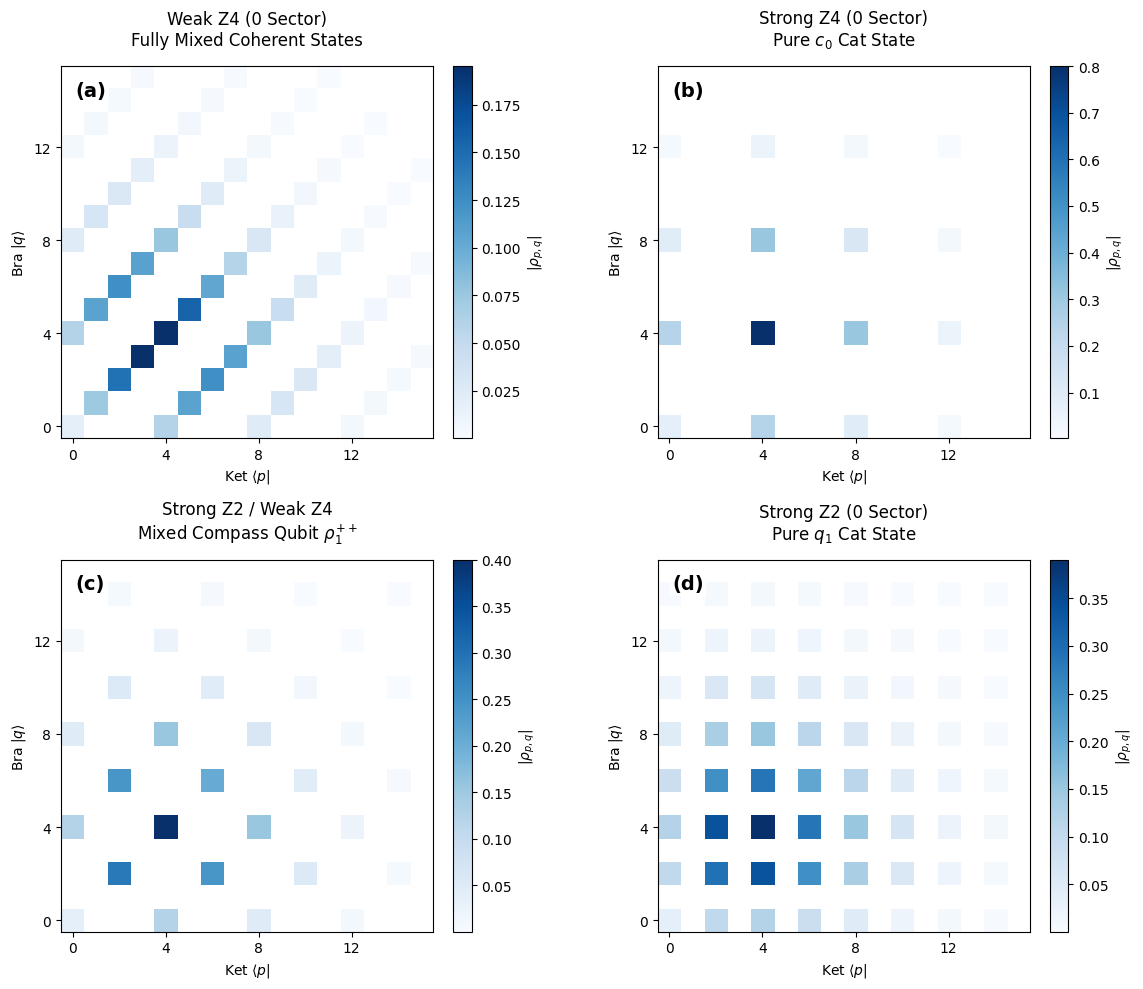

In [4]:
# Parameters
alpha = 2.0  # Coherent state amplitude
M = 16       # Fock space cutoff

# 1. Generate the Coherent State in Fock Basis
def coherent_state(alpha_val, cutoff):
    state = np.zeros(cutoff, dtype=complex)
    for n in range(cutoff):
        state[n] = (alpha_val**n / np.sqrt(factorial(n))) * np.exp(-0.5 * np.abs(alpha_val)**2)
    return state

# 2. Define the Base Coherent States
st_a = coherent_state(alpha, M)
st_ia = coherent_state(alpha * 1j, M)
st_ma = coherent_state(-alpha, M)
st_mia = coherent_state(-alpha * 1j, M)

# 3. Construct the Superposition States (Cats/Compass)
def normalize(state):
    return state / np.linalg.norm(state)

c0 = normalize(st_a + st_ia + st_ma + st_mia)
c1 = normalize(st_a - 1j*st_ia - st_ma + 1j*st_mia)
c2 = normalize(st_a - st_ia + st_ma - st_mia)
c3 = normalize(st_a + 1j*st_ia - st_ma - 1j*st_mia)
q1 = normalize(st_a + st_ma)

# 4. Construct Density Matrices
def outer_product(state):
    return np.outer(state, state.conjugate())

# Weak Z4
rho_weak_z4 = 0.25 * (outer_product(st_a) + outer_product(st_ia) + 
                      outer_product(st_ma) + outer_product(st_mia))

# Strong Z4
rho_strong_z4 = outer_product(c0)

# Strong Z2 / Weak Z4
rho_mixed_compass = 0.5 * outer_product(c0) + 0.5 * outer_product(c2)

# Strong Z2
rho_strong_z2 = outer_product(q1)

# 5. Plotting Function (Updated with subplot labels)
def plot_density_matrix(ax, rho, title, label):
    # Get absolute values of the density matrix
    abs_rho = np.abs(rho)
    
    # Mask near-zero values to show up as white
    abs_rho[abs_rho < 1e-4] = np.nan 
    
    cmap = plt.cm.Blues
    cmap.set_bad(color='white')
    
    im = ax.imshow(abs_rho, cmap=cmap, origin='lower', extent=[-0.5, M-0.5, -0.5, M-0.5])
    ax.set_title(title, fontsize=12, pad=15)
    ax.set_xlabel('Ket $\\langle p |$')
    ax.set_ylabel('Bra $| q \\rangle$')
    
    # Add the subplot label (a, b, c, d)
    ax.text(0.04, 0.96, f"({label})", transform=ax.transAxes, 
            fontsize=14, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))
    
    # Set ticks to show Fock states
    ax.set_xticks(np.arange(0, M, 4))
    ax.set_yticks(np.arange(0, M, 4))
    
    return im

# Generate the 2x2 Plot Grid
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

im1 = plot_density_matrix(axs[0, 0], rho_weak_z4, "Weak Z4 (0 Sector)\nFully Mixed Coherent States", "a")
fig.colorbar(im1, ax=axs[0, 0], fraction=0.046, pad=0.04, label="$|\\rho_{p,q}|$")

im2 = plot_density_matrix(axs[0, 1], rho_strong_z4, "Strong Z4 (0 Sector)\nPure $c_0$ Cat State", "b")
fig.colorbar(im2, ax=axs[0, 1], fraction=0.046, pad=0.04, label="$|\\rho_{p,q}|$")

im3 = plot_density_matrix(axs[1, 0], rho_mixed_compass, "Strong Z2 / Weak Z4\nMixed Compass Qubit $\\rho_1^{++}$", "c")
fig.colorbar(im3, ax=axs[1, 0], fraction=0.046, pad=0.04, label="$|\\rho_{p,q}|$")

im4 = plot_density_matrix(axs[1, 1], rho_strong_z2, "Strong Z2 (0 Sector)\nPure $q_1$ Cat State", "d")
fig.colorbar(im4, ax=axs[1, 1], fraction=0.046, pad=0.04, label="$|\\rho_{p,q}|$")

plt.tight_layout()
plt.show()

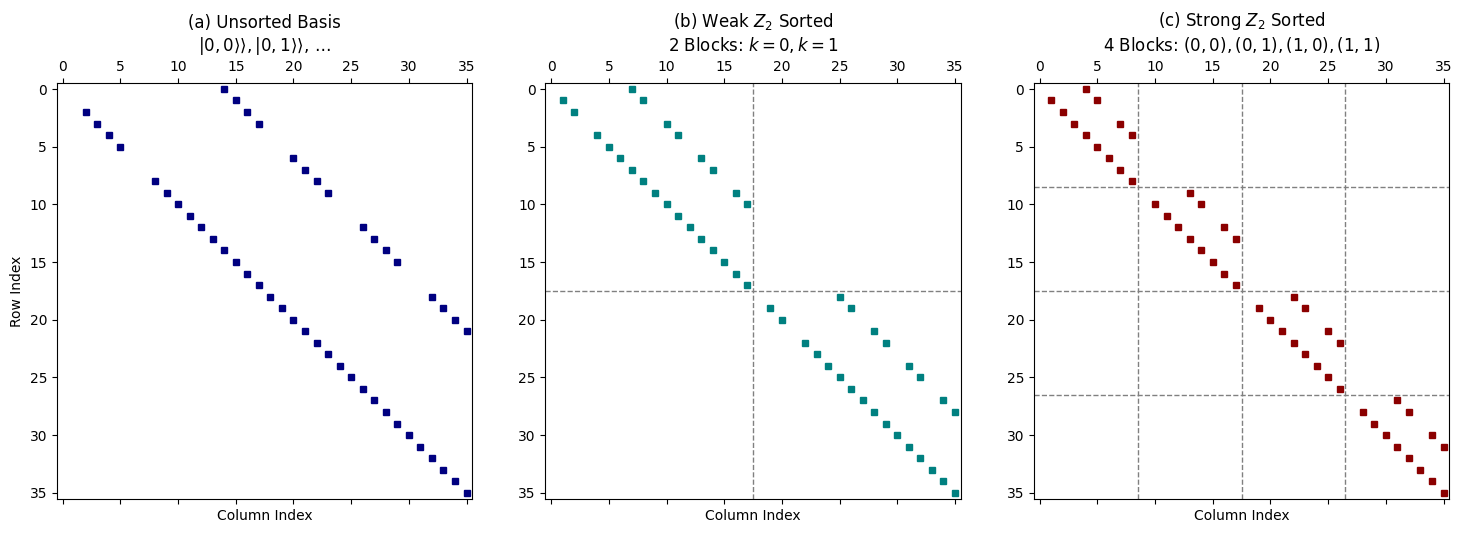

In [5]:

# Parameters
N = 6  # Small Fock space cutoff (yields a 36x36 Liouvillian)
dimL = N**2

# 1. Build the Standard Unsorted Liouvillian (2-photon dissipation toy model)
# We map |p><q| to a single index alpha = p * N + q
L_matrix = np.zeros((dimL, dimL), dtype=complex)

for p in range(N):
    for q in range(N):
        alpha = p * N + q
        
        # Hamiltonian part (e.g., simple Kerr U * a^dagger^2 a^2)
        # H |p> = U * p*(p-1) |p>
        # -i [H, rho] term:
        energy_diff = p*(p-1) - q*(q-1) 
        L_matrix[alpha, alpha] += -1j * energy_diff
        
        # Dissipator part: 2-photon loss L_jump = a^2
        # D[a^2]rho = a^2 rho a^dagger^2 - 1/2(a^dagger^2 a^2 rho + rho a^dagger^2 a^2)
        
        # Anti-commutator term (decay)
        decay_rate = p*(p-1) + q*(q-1)
        L_matrix[alpha, alpha] -= 0.5 * decay_rate
        
        # Jump term (feeding from p+2, q+2 down to p, q)
        if p + 2 < N and q + 2 < N:
            alpha_feed = (p + 2) * N + (q + 2)
            rate_in = np.sqrt((p+2)*(p+1)*(q+2)*(q+1))
            L_matrix[alpha, alpha_feed] += rate_in

# 2. Compute Permutations to Block-Diagonalize
basis = [(p, q) for p in range(N) for q in range(N)]

# Weak Z2 Sort: group by k = (p - q) % 2
basis_weak_Z2 = sorted(basis, key=lambda x: (x[0] - x[1]) % 2)
perm_weak = [p * N + q for p, q in basis_weak_Z2]

# Strong Z2 Sort: group by kL = p % 2, kR = q % 2
basis_strong_Z2 = sorted(basis, key=lambda x: (x[0] % 2, x[1] % 2))
perm_strong = [p * N + q for p, q in basis_strong_Z2]

# 3. Apply Permutations
L_weak = L_matrix[np.ix_(perm_weak, perm_weak)]
L_strong = L_matrix[np.ix_(perm_strong, perm_strong)]

# 4. Plot Sparsity Patterns
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Plot unsorted
axs[0].spy(np.abs(L_matrix) > 1e-10, markersize=4, color='navy')
axs[0].set_title("(a) Unsorted Basis\n$|0,0\\rangle\\rangle, |0,1\\rangle\\rangle, \\dots$")
axs[0].set_xlabel("Column Index")
axs[0].set_ylabel("Row Index")

# Plot weak sort
axs[1].spy(np.abs(L_weak) > 1e-10, markersize=4, color='teal')
axs[1].set_title("(b) Weak $Z_2$ Sorted\n2 Blocks: $k=0, k=1$")
axs[1].set_xlabel("Column Index")
axs[1].axhline(dimL//2 - 0.5, color='gray', linestyle='--', lw=1)
axs[1].axvline(dimL//2 - 0.5, color='gray', linestyle='--', lw=1)

# Plot strong sort
axs[2].spy(np.abs(L_strong) > 1e-10, markersize=4, color='darkred')
axs[2].set_title("(c) Strong $Z_2$ Sorted\n4 Blocks: $(0,0), (0,1), (1,0), (1,1)$")
axs[2].set_xlabel("Column Index")
for i in range(1, 4):
    axs[2].axhline((dimL//4)*i - 0.5, color='gray', linestyle='--', lw=1)
    axs[2].axvline((dimL//4)*i - 0.5, color='gray', linestyle='--', lw=1)

plt.tight_layout()
plt.show()

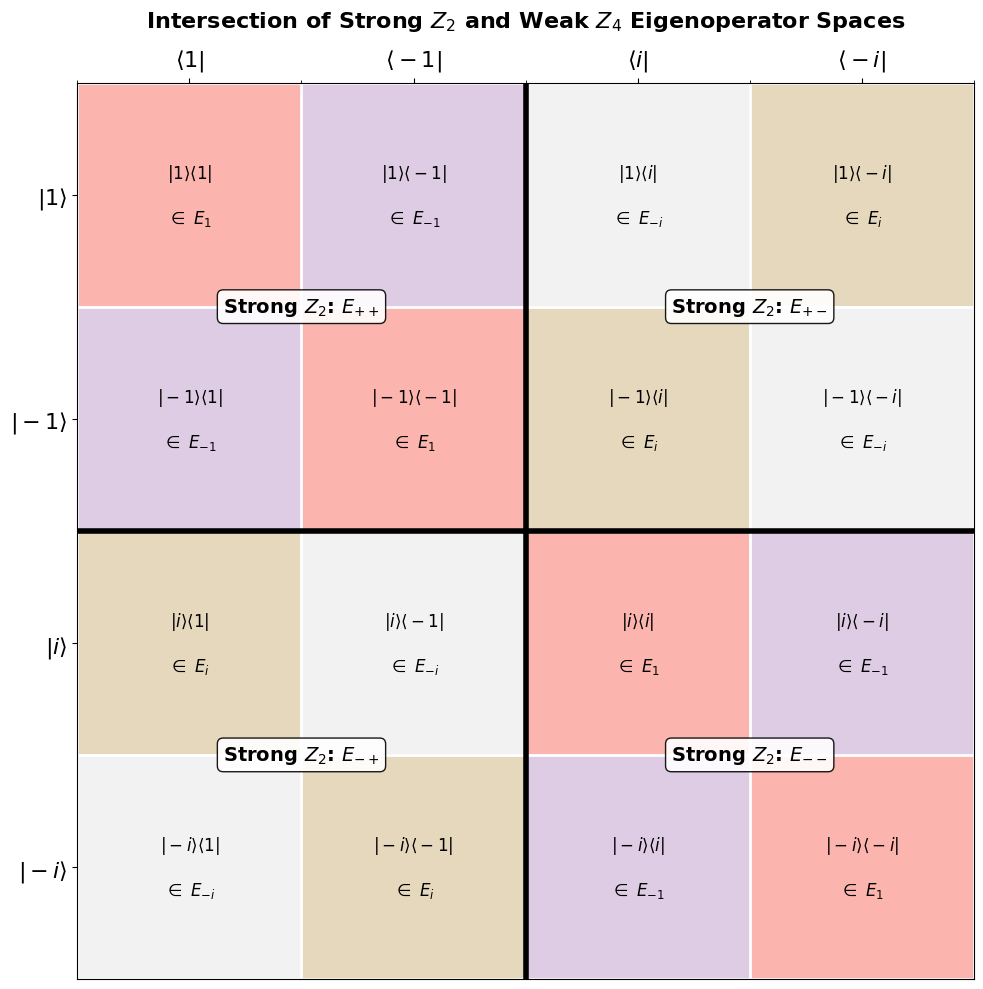

In [7]:
# 1. Define the 4x4 grid mapping the Weak Z4 Sectors
# States ordered as: |1>, |-1>, |i>, |-i>
# Sector mapping: 0 = E_1, 1 = E_-1, 2 = E_i, 3 = E_-i
grid = np.array([
    [0, 1, 3, 2],  # Ket |1>
    [1, 0, 2, 3],  # Ket |-1>
    [2, 3, 0, 1],  # Ket |i>
    [3, 2, 1, 0]   # Ket |-i>
])

# 2. Setup Plot
fig, ax = plt.subplots(figsize=(10, 10))

# Safe colormap fetch for newer Matplotlib versions
try:
    cmap = plt.colormaps['Pastel1'].resampled(4)
except AttributeError:
    cmap = plt.cm.get_cmap('Pastel1', 4)
    
im = ax.imshow(grid, cmap=cmap)

# 3. Explicitly define Ket and Bra labels to avoid TeX parsing errors
ket_labels = [r'$|1\rangle$', r'$|-1\rangle$', r'$|i\rangle$', r'$|-i\rangle$']
bra_labels = [r'$\langle 1|$', r'$\langle -1|$', r'$\langle i|$', r'$\langle -i|$']

ax.set_xticks(np.arange(4))
ax.set_yticks(np.arange(4))
ax.set_xticklabels(bra_labels, fontsize=16)
ax.set_yticklabels(ket_labels, fontsize=16)
ax.xaxis.tick_top()

# 4. Annotate each cell with its state and Weak Z4 sector
sector_names = [r'$E_1$', r'$E_{-1}$', r'$E_i$', r'$E_{-i}$']
for i in range(4):
    for j in range(4):
        # Combine the explicitly defined ket and bra
        state_label = f"{ket_labels[i]}{bra_labels[j]}"
        sector_label = sector_names[grid[i, j]]
        
        ax.text(j, i, f"{state_label}\n\n$\\in$ {sector_label}", 
                ha="center", va="center", color='black', fontsize=12)

# 5. Draw the Strong Z2 Quadrants (Thick Borders)
ax.axhline(1.5, color='black', linewidth=4)
ax.axvline(1.5, color='black', linewidth=4)

# Add Strong Z2 Labels to the corners of the quadrants
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black')
ax.text(0.5, 0.5, r'Strong $Z_2$: $E_{++}$', fontsize=14, fontweight='bold', ha='center', va='center', bbox=props)
ax.text(2.5, 2.5, r'Strong $Z_2$: $E_{--}$', fontsize=14, fontweight='bold', ha='center', va='center', bbox=props)
ax.text(2.5, 0.5, r'Strong $Z_2$: $E_{+-}$', fontsize=14, fontweight='bold', ha='center', va='center', bbox=props)
ax.text(0.5, 2.5, r'Strong $Z_2$: $E_{-+}$', fontsize=14, fontweight='bold', ha='center', va='center', bbox=props)

# 6. Final Formatting
ax.set_title("Intersection of Strong $Z_2$ and Weak $Z_4$ Eigenoperator Spaces", fontsize=16, pad=40, fontweight='bold')
ax.set_xticks(np.arange(-.5, 4, 1), minor=True)
ax.set_yticks(np.arange(-.5, 4, 1), minor=True)
ax.grid(which="minor", color="w", linestyle='-', linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(axis='both', which='major', labelsize=16)

plt.tight_layout()
plt.show()